## 2. DP1 coadd display and cutouts

This notebook demonstrates how to inspect DP1 ComCam--VISTA coadd images from the lsst-ir-fusion-dp1 Butler repository.

The example target is the UDG candidate SMDG-J0333094-280938, located at:

RA = 53.28911 deg
Dec = -28.16056 deg

The notebook connects to the Butler, selects the appropriate skymap, identifies the tract and patch containing the target position, and searches for available coadd images. It then displays the selected coadd, inspects its mask planes, creates a single-band cutout centred on the target, and makes a simple RGB cutout when suitable bands are available.

After changing the repository path or target coordinates, restart the kernel and run the notebook from the beginning.

### 2.1 Imports

We use Butler tools for data access, LSST geometry for sky positions, and matplotlib for robust display inside RSP notebooks.


In [1]:
import gc
import itertools

import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_lupton_rgb

import lsst.daf.butler as dafButler
import lsst.geom
import lsst.afw.display as afwDisplay

afwDisplay.setDefaultBackend("matplotlib")

plt.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 13,
    "figure.figsize": (8, 6),
})


def remove_figure(fig=None):
    """Close a matplotlib figure and free memory."""
    if fig is None:
        fig = plt.gcf()
    plt.close(fig)
    gc.collect()


### 2.2 Configuration

The default target is one UDG in ECDFS/CDFS. You can later replace the RA and Dec with another target.


In [2]:
# Butler repository label on UK RSP.
REPO = "lsst-ir-fusion-dp1"

# Default target: your UDG in ECDFS/CDFS.
TARGET_NAME = "UDG SMDG-J0333094-280938"
TARGET_RA_DEG = 53.28911
TARGET_DEC_DEG = -28.16056

# DP1 ComCam--VISTA products should normally use this skymap.
PREFERRED_SKYMAP = "lsst_cells_v1"

# Band priority for the single-band display.
PREFERRED_BANDS = ["K", "Ks", "H", "J", "Y", "Z", "i", "r", "g", "z", "y", "u"]

# Candidate bands for a simple RGB cutout.
RGB_BAND_CANDIDATES = {
    "red": ["K", "Ks", "H", "i", "z", "y"],
    "green": ["J", "H", "r", "i"],
    "blue": ["Y", "Z", "g", "u"],
}

CUTOUT_SIDE_PIXELS = 300

# Search all collections by default. If this is slow, inspect cell 2.4 and set
# SEARCH_COLLECTIONS to a list of the relevant output collections.
SEARCH_COLLECTIONS = ...

# Optional manual override if you already know the exact data ID.
# Example: DATA_ID_OVERRIDE = {"skymap": "lsst_cells_v1", "tract": 5063, "patch": 14}
DATA_ID_OVERRIDE = None


### 2.3 Open the Butler

This opens the DP1 repository and stores the registry object for product discovery.


In [3]:
butler = dafButler.Butler(REPO)
registry = butler.registry

print("Opened Butler repository:", REPO)
print("Target:", TARGET_NAME)
print(f"RA, Dec [deg]: {TARGET_RA_DEG:.6f}, {TARGET_DEC_DEG:.6f}")


Opened Butler repository: lsst-ir-fusion-dp1
Target: UDG SMDG-J0333094-280938
RA, Dec [deg]: 53.289110, -28.160560


### 2.4 Inspect available collections

This is only a diagnostic cell.


In [4]:
all_collections = sorted(registry.queryCollections())

print(f"Number of collections found: {len(all_collections)}")
print("Available collections:")
for collection in all_collections:
    print(" ", collection)

print()
if SEARCH_COLLECTIONS is ...:
    print("Current search setting: all collections")
else:
    print("Current search setting:")
    for collection in SEARCH_COLLECTIONS:
        print(" ", collection)


Number of collections found: 4
Available collections:
  skymaps
  u/ir-sare1/DRP/videoCoaddDetect
  u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z

Current search setting: all collections


### 2.5 Inspect coadd dataset types


In [5]:
all_dataset_types = sorted(registry.queryDatasetTypes(), key=lambda dt: dt.name)
dataset_type_names = [dt.name for dt in all_dataset_types]

print(f"Number of dataset types found: {len(dataset_type_names)}")
print()


def show_dataset_types_matching(words, max_rows=200):
    """Print dataset types whose names contain at least one of the given words."""
    words = tuple(word.lower() for word in words)
    matches = []
    for dt in all_dataset_types:
        lower = dt.name.lower()
        if any(word in lower for word in words):
            dims = ", ".join(sorted(dt.dimensions.names))
            matches.append((dt.name, dims, str(dt.storageClass)))

    print(f"Matching dataset types: {len(matches)}")
    for name, dims, storage in matches[:max_rows]:
        print(f"{name:40s}  dims=[{dims}]  storage={storage}")
    if len(matches) > max_rows:
        print(f"... {len(matches) - max_rows} more matches not printed")
    return matches


coadd_type_matches = show_dataset_types_matching(["coadd", "deepcoadd"])


Number of dataset types found: 4

Matching dataset types: 3
deepCoadd_calexp                          dims=[band, patch, skymap, tract]  storage=ExposureF
deepCoadd_forced_src                      dims=[band, patch, skymap, tract]  storage=SourceCatalog
deepCoadd_meas                            dims=[band, patch, skymap, tract]  storage=SourceCatalog


### 2.6 Select the skymap

The skymap gives the tract and patch geometry for the target coordinates.


In [6]:
def query_limited(dataset_type_name, data_id=None, collections=None, max_refs=50):
    """Query a dataset type and return at most max_refs refs."""
    if collections is None:
        collections = SEARCH_COLLECTIONS

    try:
        kwargs = {"dataId": data_id}
        if collections is ...:
            kwargs["collections"] = ...
        else:
            kwargs["collections"] = collections
        query = registry.queryDatasets(dataset_type_name, **kwargs)
        return list(itertools.islice(query, max_refs))
    except Exception as err:
        print(f"Could not query {dataset_type_name!r}: {type(err).__name__}: {err}")
        return []


skyMap_refs = []
try:
    skyMap_refs = list(registry.queryDatasets("skyMap", collections="skymaps"))
except Exception as err:
    print("Could not query skyMap in collection 'skymaps':", repr(err))

if not skyMap_refs:
    skyMap_refs = query_limited("skyMap", collections=SEARCH_COLLECTIONS, max_refs=200)

if not skyMap_refs:
    raise RuntimeError("No skyMap dataset was found. Check the repository and collection settings.")

available_skymaps = sorted({ref.dataId["skymap"] for ref in skyMap_refs})
print("Available skymaps:")
for name in available_skymaps:
    print(" ", name)

if PREFERRED_SKYMAP in available_skymaps:
    skymap_name = PREFERRED_SKYMAP
else:
    skymap_name = available_skymaps[0]
    print(f"Preferred skymap {PREFERRED_SKYMAP!r} was not found; using {skymap_name!r} instead.")

selected_skyMap_ref = next(ref for ref in skyMap_refs if ref.dataId["skymap"] == skymap_name)
print("Using skymap:", skymap_name)
print("skyMap run  :", selected_skyMap_ref.run)


Available skymaps:
  lsst_cells_v1
Using skymap: lsst_cells_v1
skyMap run  : skymaps


### 2.7 Convert the UDG position to tract and patch


In [7]:
target_sphere_point = lsst.geom.SpherePoint(
    TARGET_RA_DEG * lsst.geom.degrees,
    TARGET_DEC_DEG * lsst.geom.degrees,
)

skymap = butler.get(selected_skyMap_ref)
tract_info = skymap.findTract(target_sphere_point)
patch_info = tract_info.findPatch(target_sphere_point)

my_tract = tract_info.getId()
my_patch = patch_info.getSequentialIndex()

data_id_base = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
}

if DATA_ID_OVERRIDE is not None:
    data_id_base.update(DATA_ID_OVERRIDE)

print("Target:", TARGET_NAME)
print("RA, Dec [deg]:", TARGET_RA_DEG, TARGET_DEC_DEG)
print("base dataId:", data_id_base)
try:
    print("patch index:", patch_info.getIndex())
except Exception:
    pass


Target: UDG SMDG-J0333094-280938
RA, Dec [deg]: 53.28911 -28.16056
base dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
patch index: Index2D(x=3, y=1)


### 2.8 Helper functions

These functions keep the coadd search and display robust across slightly different Butler product definitions.


In [8]:
def data_id_to_dict(data_id):
    """Convert a Butler DataCoordinate to a normal dictionary for printing."""
    for attr in ("required", "mapping"):
        try:
            return dict(getattr(data_id, attr))
        except Exception:
            pass
    try:
        return {key: data_id[key] for key in data_id.keys()}
    except Exception:
        return str(data_id)


def dataset_type_exists(dataset_type_name):
    try:
        registry.getDatasetType(dataset_type_name)
        return True
    except Exception:
        return False


def dimensions_of(dataset_type_name):
    return set(registry.getDatasetType(dataset_type_name).dimensions.names)


def compatible_data_id(dataset_type_name, base_data_id):
    dims = dimensions_of(dataset_type_name)
    return {key: value for key, value in base_data_id.items() if key in dims}


def summarize_refs(refs, max_rows=20):
    print(f"Number of refs found: {len(refs)}")
    for ref in refs[:max_rows]:
        print(" ", ref.datasetType.name, data_id_to_dict(ref.dataId), "run=", ref.run)
    if len(refs) > max_rows:
        print(f" ... {len(refs) - max_rows} more refs not printed")


def query_product(dataset_type_name, base_data_id=None, max_refs=100):
    if not dataset_type_exists(dataset_type_name):
        return []
    query_data_id = None if base_data_id is None else compatible_data_id(dataset_type_name, base_data_id)
    print()
    print("Dataset type:", dataset_type_name)
    print("Dimensions  :", sorted(dimensions_of(dataset_type_name)))
    print("Query dataId:", query_data_id)
    refs = query_limited(dataset_type_name, data_id=query_data_id, collections=SEARCH_COLLECTIONS, max_refs=max_refs)
    summarize_refs(refs)
    return refs


def data_id_value(ref, key):
    try:
        return ref.dataId[key]
    except Exception:
        return None


def exposure_image_array(exposure):
    try:
        return np.asarray(exposure.image.array, dtype=float)
    except Exception:
        return np.asarray(exposure.maskedImage.image.array, dtype=float)


def percentile_limits(image_array, percentiles=(1, 99)):
    finite = np.isfinite(image_array)
    if not np.any(finite):
        raise RuntimeError("The image array contains no finite pixels.")
    vmin, vmax = np.nanpercentile(image_array[finite], percentiles)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = np.nanmin(image_array[finite])
        vmax = np.nanmax(image_array[finite])
    return vmin, vmax


def plot_image_array(image_array, title, extent=None, target_xy=None, figsize=(8, 8)):
    vmin, vmax = percentile_limits(image_array)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(
        image_array,
        origin="lower",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax,
        extent=extent,
        cmap="gray",
    )
    if target_xy is not None:
        ax.scatter([target_xy[0]], [target_xy[1]], marker="+", s=180)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("x [parent pixel]" if extent is not None else "x [pixel]")
    ax.set_ylabel("y [parent pixel]" if extent is not None else "y [pixel]")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="image value")
    fig.tight_layout()
    plt.show()
    return fig, ax


### 2.9 Find coadd images at the UDG position

The notebook tests the common coadd dataset types and uses the first one found at the target patch.


In [9]:
PREFERRED_COADD_DATASET_TYPES = [
    "deepCoadd_calexp",
    "deepCoadd",
    "deepCoadd_directWarp",
    "deepCoadd_psfMatchedWarp",
]

available_coadd_dataset_types = [name for name in PREFERRED_COADD_DATASET_TYPES if dataset_type_exists(name)]
print("Preferred coadd dataset types available:")
for name in available_coadd_dataset_types:
    print(" ", name)

coadd_dataset_type = None
coadd_refs = []
for dataset_type_name in available_coadd_dataset_types:
    refs = query_product(dataset_type_name, data_id_base, max_refs=500)
    if refs:
        coadd_dataset_type = dataset_type_name
        coadd_refs = refs
        break

if coadd_dataset_type is None:
    print("No coadd refs were found at the selected patch.")
    print("Trying a tract-level diagnostic query without patch.")
    tract_data_id = {k: v for k, v in data_id_base.items() if k != "patch"}
    for dataset_type_name in available_coadd_dataset_types:
        refs = query_product(dataset_type_name, tract_data_id, max_refs=30)
        if refs:
            print("This tract has coadds, but not for the selected patch. Check target coordinates or patch geometry.")
            break
    raise RuntimeError("No coadd image was found for the selected target patch.")

print("Using coadd dataset type:", coadd_dataset_type)


Preferred coadd dataset types available:
  deepCoadd_calexp

Dataset type: deepCoadd_calexp
Dimensions  : ['band', 'patch', 'skymap', 'tract']
Query dataId: {'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Number of refs found: 5
  deepCoadd_calexp {'band': 'H', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
  deepCoadd_calexp {'band': 'Z', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Using coadd dataset type: deepCoadd_calexp


### 2.10 Select a display band

The code chooses the first available band from `PREFERRED_BANDS`.


In [10]:
coadd_refs_by_band = {}
for ref in coadd_refs:
    band = data_id_value(ref, "band")
    if band is None:
        band = data_id_value(ref, "physical_filter")
    if band is None:
        band = "unknown"
    coadd_refs_by_band.setdefault(str(band), ref)

available_coadd_bands = sorted(coadd_refs_by_band)
print("Available coadd bands at this patch:", available_coadd_bands)

selected_band = None
selected_coadd_ref = None
for band in PREFERRED_BANDS:
    if band in coadd_refs_by_band:
        selected_band = band
        selected_coadd_ref = coadd_refs_by_band[band]
        break

if selected_coadd_ref is None:
    selected_band = available_coadd_bands[0]
    selected_coadd_ref = coadd_refs_by_band[selected_band]

print("Selected band:", selected_band)
print("Selected coadd ref:", selected_coadd_ref.datasetType.name, data_id_to_dict(selected_coadd_ref.dataId), "run=", selected_coadd_ref.run)


Available coadd bands at this patch: ['H', 'J', 'K', 'Y', 'Z']
Selected band: K
Selected coadd ref: deepCoadd_calexp {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13} run= u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z


### 2.11 Display the full coadd patch

This uses `matplotlib.imshow`, which is usually more reliable than `afwDisplay.mtv` in Jupyter/RSP. The UDG position is marked with a plus sign.


Retrieved: deepCoadd_calexp
Data ID  : {'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
Type     : <class 'lsst.afw.image._exposure.ExposureF'>
Shape    : (3400, 3400)


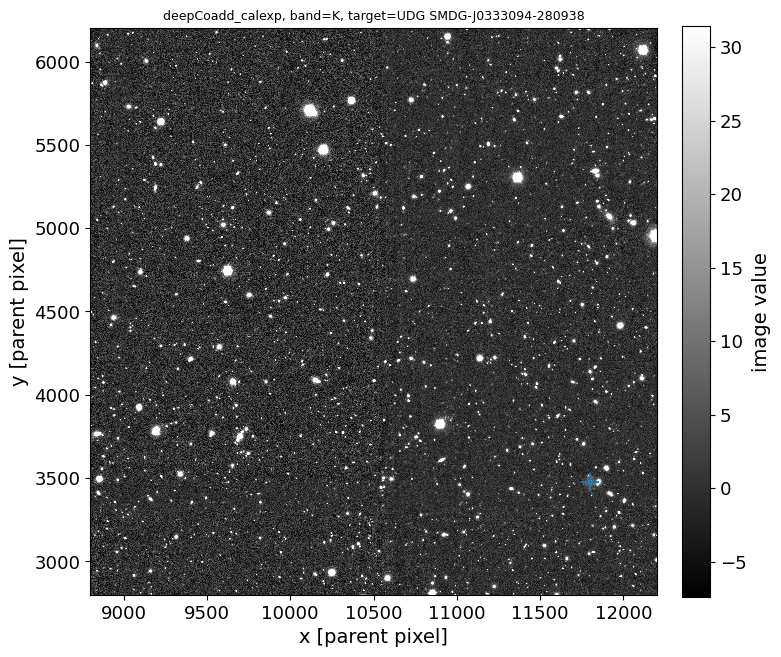

In [11]:
coadd = butler.get(selected_coadd_ref)
image_array = exposure_image_array(coadd)

print("Retrieved:", selected_coadd_ref.datasetType.name)
print("Data ID  :", data_id_to_dict(selected_coadd_ref.dataId))
print("Type     :", type(coadd))
print("Shape    :", image_array.shape)

try:
    bbox = coadd.getBBox()
    full_extent = [bbox.getMinX(), bbox.getMaxX() + 1, bbox.getMinY(), bbox.getMaxY() + 1]
except Exception:
    bbox = None
    full_extent = None

try:
    target_pixel = coadd.getWcs().skyToPixel(target_sphere_point)
    target_xy = (target_pixel.getX(), target_pixel.getY())
except Exception as err:
    print("Could not compute target pixel position:", repr(err))
    target_xy = None

fig, ax = plot_image_array(
    image_array,
    title=f"{selected_coadd_ref.datasetType.name}, band={selected_band}, target={TARGET_NAME}",
    extent=full_extent,
    target_xy=target_xy,
    figsize=(8, 8),
)


### 2.12 Inspect mask planes

Mask planes show flags such as `DETECTED`, `BAD`, `SAT`, and `EDGE` when they exist.


In [12]:
try:
    mask_plane_dict = coadd.mask.getMaskPlaneDict()
except Exception:
    mask_plane_dict = {}

if not mask_plane_dict:
    print("No mask plane dictionary was found for this object.")
else:
    print("Mask planes in this image:\n")
    for name, bit in sorted(mask_plane_dict.items(), key=lambda x: x[1]):
        print(f"{bit:2d}  {name}")


Mask planes in this image:

 0  BAD
 1  SAT
 2  INTRP
 3  CR
 4  EDGE
 5  DETECTED
 6  DETECTED_NEGATIVE
 7  SUSPECT
 8  NO_DATA
 9  VIGNETTED
10  STREAK
11  CLIPPED
12  INEXACT_PSF
13  NOT_DEBLENDED
14  REJECTED
15  SENSOR_EDGE
16  UNMASKEDNAN


### 2.13 Optional Rubin-style display with mask overlay

This cell uses `afwDisplay` to show the full LSST exposure. Since an exposure contains the image, mask, and variance planes, the display includes a mask overlay on top of the science image. This is useful for checking whether the target is affected by mask planes such as `DETECTED`, `BAD`, or `EDGE`.


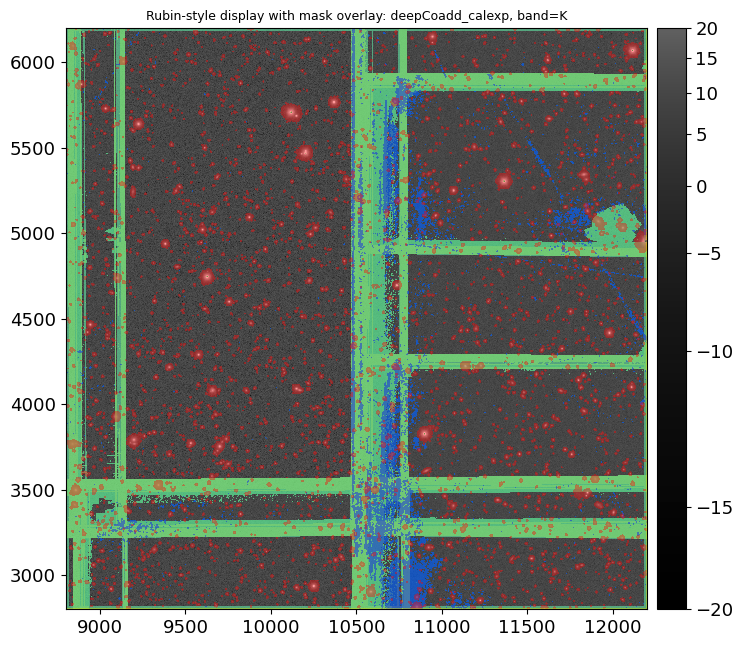

In [13]:
if mask_plane_dict:
    fig = plt.figure(figsize=(8, 8))
    rsp_display = afwDisplay.Display(frame=fig)
    rsp_display.scale("asinh", "zscale")
    rsp_display.setMaskTransparency(60)

    if "DETECTED" in mask_plane_dict:
        rsp_display.setMaskPlaneColor("DETECTED", "red")
    if "BAD" in mask_plane_dict:
        rsp_display.setMaskPlaneColor("BAD", "cyan")
    if "EDGE" in mask_plane_dict:
        rsp_display.setMaskPlaneColor("EDGE", "yellow")

    rsp_display.mtv(coadd)
    plt.title(
        f"Rubin-style display with mask overlay: {selected_coadd_ref.datasetType.name}, "
        f"band={selected_band}",
        fontsize=9,
    )
    plt.show()
    remove_figure(fig)
else:
    print("Mask overlay skipped because no mask plane dictionary was available.")


### 2.14 Define the cutout function

The cutout is made from the loaded coadd exposure using its WCS and parent-pixel bounding box.


In [14]:
def make_array_cutout(exposure, ra_deg, dec_deg, side_pixels=300):
    """Return a cutout array, parent-pixel extent, and target pixel position."""
    sky_position = lsst.geom.SpherePoint(ra_deg * lsst.geom.degrees, dec_deg * lsst.geom.degrees)
    pixel_position = exposure.getWcs().skyToPixel(sky_position)
    x_center = int(round(pixel_position.getX()))
    y_center = int(round(pixel_position.getY()))

    image_bbox = exposure.getBBox()
    half = side_pixels // 2

    x0 = max(x_center - half, image_bbox.getMinX())
    y0 = max(y_center - half, image_bbox.getMinY())
    x1 = min(x0 + side_pixels, image_bbox.getMaxX() + 1)
    y1 = min(y0 + side_pixels, image_bbox.getMaxY() + 1)

    if x0 >= x1 or y0 >= y1:
        raise RuntimeError("The requested cutout does not overlap this coadd image.")

    image = exposure_image_array(exposure)
    rel_x0 = x0 - image_bbox.getMinX()
    rel_x1 = x1 - image_bbox.getMinX()
    rel_y0 = y0 - image_bbox.getMinY()
    rel_y1 = y1 - image_bbox.getMinY()

    cutout_array = image[rel_y0:rel_y1, rel_x0:rel_x1]
    cutout_extent = [x0, x1, y0, y1]
    target_xy = (pixel_position.getX(), pixel_position.getY())
    return cutout_array, cutout_extent, target_xy


### 2.15 Display a single-band cutout around the UDG

This cutout uses the selected band from cell 2.10.


Cutout shape: (300, 300)
Cutout extent [parent pixels]: [11650, 11950, 3328, 3628]


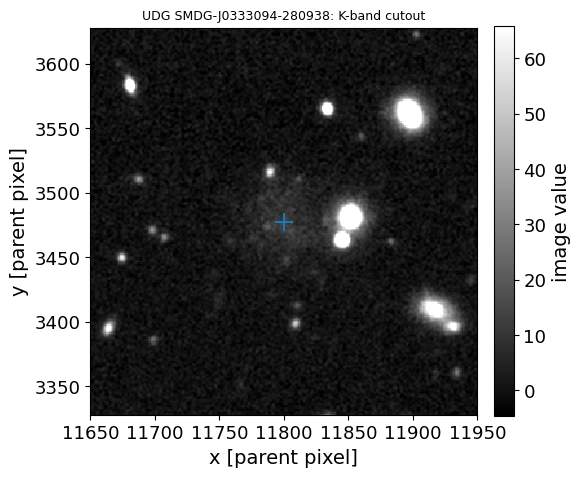

In [15]:
cutout_array, cutout_extent, cutout_target_xy = make_array_cutout(
    coadd,
    TARGET_RA_DEG,
    TARGET_DEC_DEG,
    side_pixels=CUTOUT_SIDE_PIXELS,
)

print("Cutout shape:", cutout_array.shape)
print("Cutout extent [parent pixels]:", cutout_extent)

fig, ax = plot_image_array(
    cutout_array,
    title=f"{TARGET_NAME}: {selected_band}-band cutout",
    extent=cutout_extent,
    target_xy=cutout_target_xy,
    figsize=(6, 6),
)


### 2.16 Select bands for a simple RGB cutout

The preferred VISTA-style RGB is red = `K`/`Ks`, green = `J`, and blue = `Y`. The code falls back to nearby optical/NIR bands if needed.


In [16]:
rgb_refs = {}
used_bands = set()

for channel, candidate_bands in RGB_BAND_CANDIDATES.items():
    for band in candidate_bands:
        if band in coadd_refs_by_band and band not in used_bands:
            rgb_refs[channel] = coadd_refs_by_band[band]
            used_bands.add(band)
            break

print("Selected RGB refs:")
for channel in ("red", "green", "blue"):
    ref = rgb_refs.get(channel)
    if ref is None:
        print(f"  {channel:5s}: missing")
    else:
        print(f"  {channel:5s}: band={data_id_value(ref, 'band')}  dataId={data_id_to_dict(ref.dataId)}")

if set(rgb_refs) != {"red", "green", "blue"}:
    print("RGB cutout will be skipped because fewer than three suitable bands were found.")


Selected RGB refs:
  red  : band=K  dataId={'band': 'K', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
  green: band=J  dataId={'band': 'J', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}
  blue : band=Y  dataId={'band': 'Y', 'skymap': 'lsst_cells_v1', 'tract': 5063, 'patch': 13}


### 2.17 Build and display the RGB cutout

This colour image is only for visual inspection, not quantitative photometry.


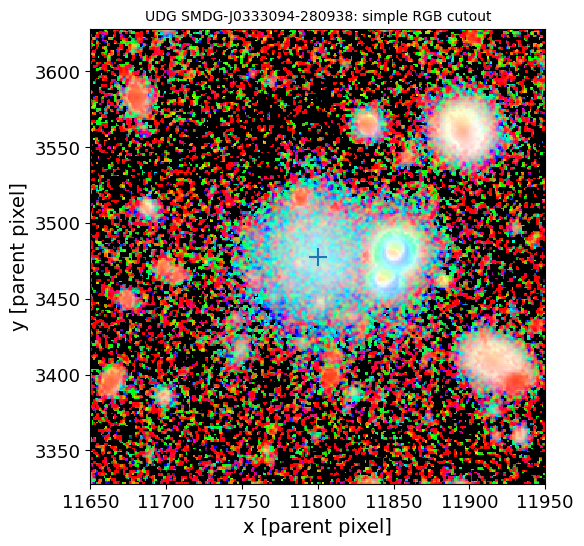

In [17]:
if set(rgb_refs) == {"red", "green", "blue"}:
    rgb_cutouts = {}

    for channel, ref in rgb_refs.items():
        exposure = butler.get(ref)
        arr, extent, xy = make_array_cutout(
            exposure,
            TARGET_RA_DEG,
            TARGET_DEC_DEG,
            side_pixels=CUTOUT_SIDE_PIXELS,
        )

        finite = np.isfinite(arr)
        fill_value = np.nanmedian(arr[finite]) if np.any(finite) else 0.0
        rgb_cutouts[channel] = np.nan_to_num(arr, nan=fill_value, posinf=fill_value, neginf=fill_value)

    rgb = make_lupton_rgb(
        rgb_cutouts["red"],
        rgb_cutouts["green"],
        rgb_cutouts["blue"],
        stretch=0.5,
        Q=8,
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(rgb, origin="lower", extent=extent, interpolation="nearest")
    ax.scatter([xy[0]], [xy[1]], marker="+", s=180)
    ax.set_title(f"{TARGET_NAME}: simple RGB cutout", fontsize=10)
    ax.set_xlabel("x [parent pixel]")
    ax.set_ylabel("y [parent pixel]")
    fig.tight_layout()
    plt.show()
else:
    print("RGB cutout skipped.")


### 2.18 Try another target

To inspect a different object, edit `TARGET_NAME`, `TARGET_RA_DEG`, and `TARGET_DEC_DEG` in cell 2.2, then restart the kernel and run all cells again.

To change the cutout size, edit `CUTOUT_SIDE_PIXELS` in cell 2.2.

If no coadd is found, check that the target is inside the DP1 ComCam--VISTA footprint, the repository is `lsst-ir-fusion-dp1`, and the relevant output collection is included in `SEARCH_COLLECTIONS`.
